In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from PIL import Image
import matplotlib.font_manager as fm

In [7]:
### CHANGING DEFAULT FONT ###
# available_fonts = sorted([f.name for f in fm.fontManager.ttflist])
# print(available_fonts)

plt.rcParams['font.family'] = 'Arial' 

<font color='red' size = 6>Load in data</font>

In [8]:
# (to produce the alingment, use 'QX1410_AF16_nucmer.sh')   
QX_AF = pd.read_csv("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/alignments/QX1410_AF16_transformed.tsv", sep="\t", header=0, names=["QS","QE","AS","AE","LQ","LA","IDY","LENR","LENQ","QX_chr","AF_chr_contig"])
QX_AF[:5]

,QS,QE,AS,AE,LQ,LA,IDY,LENR,LENQ,QX_chr,AF_chr_contig
0,15888,17290,16626596,16625197,1403,1400,99.79,15540809,16627154,I,II
1,15888,17972,3494,1412,2085,2083,99.52,15540809,8253,I,cb25.fpc4500
2,18569,21839,3274,1,3271,3274,98.87,15540809,5869,I,cb25.NA_289
3,19151,26360,1,7209,7210,7209,99.61,15540809,8253,I,cb25.fpc4500
4,29285,30546,7019373,7020634,1262,1262,99.68,15540809,17485439,I,IV


<font color='red' size = 6>Data manipulation for plotting</font>

In [9]:
QX_AF['QS_Mb'] = QX_AF['QS'] / 1e6
QX_AF['QE_Mb'] = QX_AF['QE'] / 1e6
QX_AF['AS_Mb'] = QX_AF['AS'] / 1e6
QX_AF['AE_Mb'] = QX_AF['AE'] / 1e6
chromosomes = QX_AF['QX_chr'].unique()

# Assign each alignment a category 
QX_AF['assignment'] = np.where(
    QX_AF['QX_chr'] == QX_AF['AF_chr_contig'], QX_AF['QX_chr'],  # Matches chromosome
    np.where(
        QX_AF['AF_chr_contig'].str.startswith('cb'), 'unplaced',  # Starts with 'cb'
        np.where(QX_AF['AF_chr_contig'].isin(chromosomes), 'misaligned', 'other')  # Different but still a chromosome
    )
)
# print(QX_AF[['QX_chr', 'AF_chr_contig', 'assignment']].head(40))

# Manually assigning colors to contigs based on alignment
color_map = {'unplaced': 'red', 'misaligned': 'darkgoldenrod', 'other': 'navy'}
for chrom in chromosomes:
    color_map[chrom] = '#759885'  #hex color of C. briggsae

# Assign color to each row based on key (assignment) and value (color)
QX_AF['color'] = QX_AF['assignment'].map(color_map)

ordered_chromosomes_plot1 = ['I', 'II', 'III']
ordered_chromosomes_plot2 = ['IV', 'V', 'X']

<font color='red' size = 6>Plotting</font>

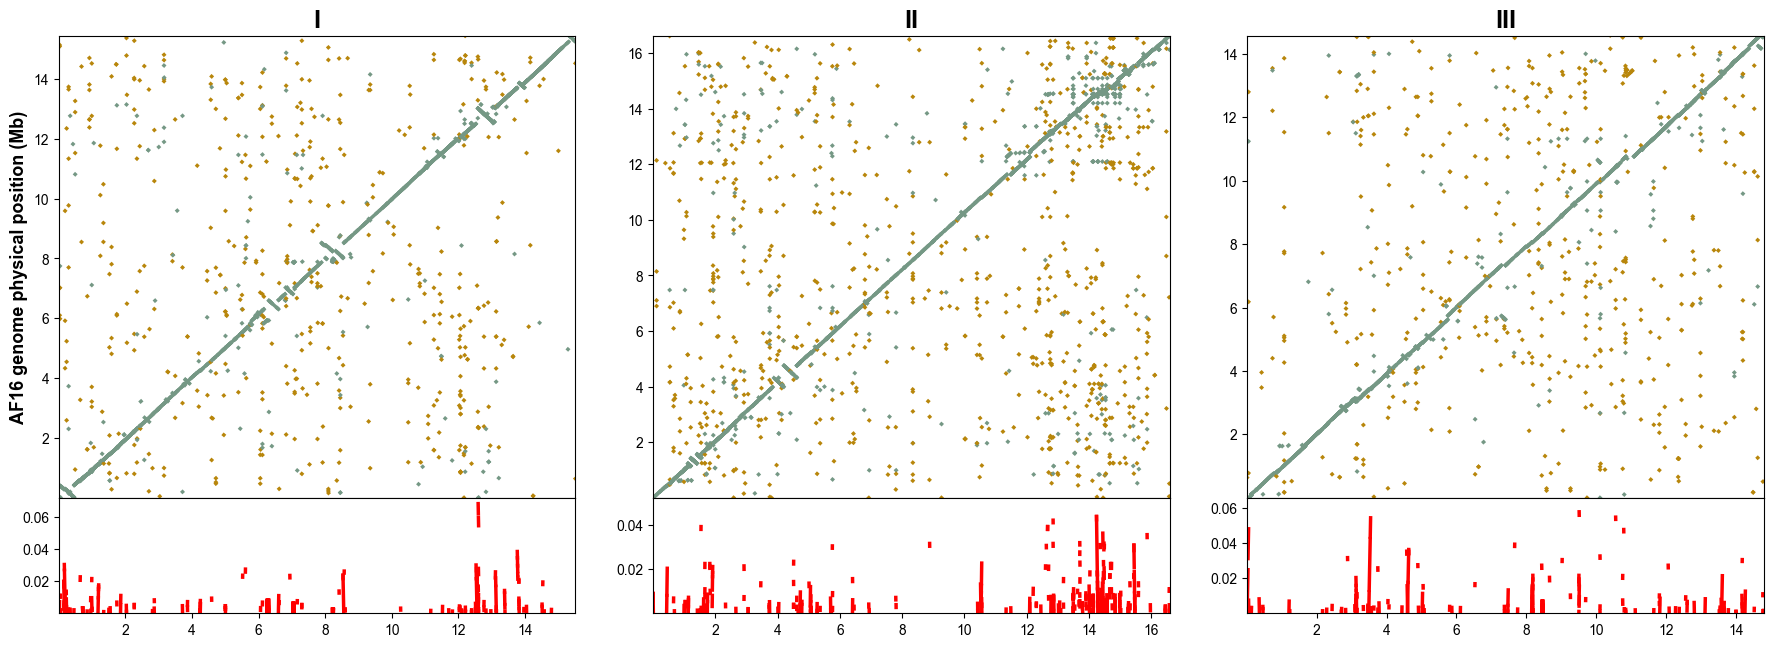

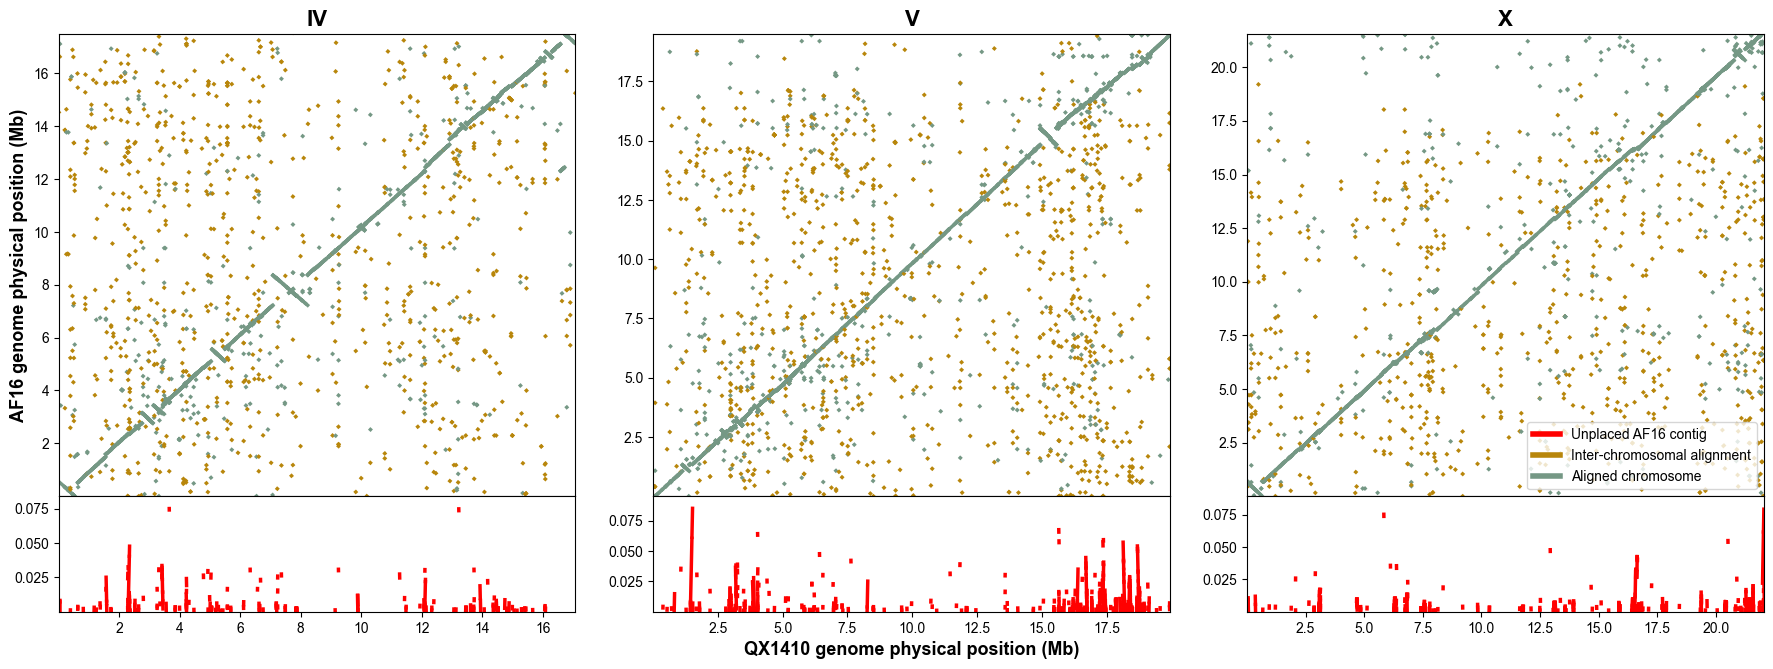

In [10]:
# PLOT 1 
fig1 = plt.figure(figsize=(22, 7.5))
gs1 = gridspec.GridSpec(2, 3, height_ratios=[1, 0.25]) # chromosome plots are scaled normally, with contig plots smaller
gs1.update(wspace = 0.15, hspace=0) 

ax_chr1 = [fig1.add_subplot(gs1[0, i]) for i in range(3)]
ax_contig1 = [fig1.add_subplot(gs1[1, i]) for i in range(3)]

for i, chrom in enumerate(ordered_chromosomes_plot1):
    ax_chromosome = ax_chr1[i]
    
    chrom_data_noUnplaced = QX_AF[(QX_AF['QX_chr'] == chrom) & (QX_AF['assignment'] != 'unplaced')]
    unplaced_data = QX_AF[(QX_AF['QX_chr'] == chrom) & (QX_AF['assignment'] == 'unplaced')]
    
    valid_AE_Mb = chrom_data_noUnplaced[chrom_data_noUnplaced['assignment'] == chrom]['AE_Mb']
    valid_QE_Mb = chrom_data_noUnplaced[chrom_data_noUnplaced['assignment'] == chrom]['QE_Mb']
    
    # Plot chromosomes
    for _, row in chrom_data_noUnplaced.iterrows():
        ax_chromosome.plot(
            [row['QS_Mb'], row['QE_Mb']], [row['AS_Mb'], row['AE_Mb']], 
            color=row['color'], alpha=1, linewidth=2.5
        )
    
    ax_chromosome.set_title(f"{chrom}", size=18, fontweight = 'bold')
    ax_chromosome.set_ylim(min(QX_AF['AS_Mb']), max(valid_AE_Mb))
    ax_chromosome.set_xlim(min(QX_AF['QS_Mb']), max(valid_QE_Mb))

    # Plot unplaced contigs
    ax_unplaced = ax_contig1[i]
    for _, row in unplaced_data.iterrows():
        ax_unplaced.plot(
            [row['QS_Mb'], row['QE_Mb']], [row['AS_Mb'], row['AE_Mb']], 
            color=row['color'], alpha=1, linewidth=2.5
        )
    ax_unplaced.set_ylim(min(unplaced_data['AS_Mb']), max(unplaced_data['AE_Mb']) + 0.01)

    ax_chromosome.set_xticklabels([])
    ax_chromosome.set_xlabel('')

    ax_unplaced.set_xlim(min(QX_AF['QS_Mb']), max(chrom_data_noUnplaced['QE_Mb']))
    ax_chromosome.set_xlim(min(QX_AF['QS_Mb']), max(chrom_data_noUnplaced['QE_Mb']))

# Add legend
# handles = [
#     plt.Line2D([0], [0], color=color_map['unplaced'], lw=4, label='Unplaced AF16 contig'),
#     plt.Line2D([0], [0], color=color_map['misaligned'], lw=4, label='Inter-chromosomal alignment'),
#     plt.Line2D([0], [0], color='#759885', lw=4, label='Aligned chromosome')
# ]
# ax_contig1[2].legend(handles=handles, title="Placement", loc='upper right', facecolor='white')

ax_chr1[0].set_ylabel("AF16 genome physical position (Mb)", size=13, fontweight='bold')
# ax_contig1[1].set_xlabel("QX1410 genome physical position (Mb)", size=14, fontweight='bold')

plt.show()




# PLOT 2 
fig2 = plt.figure(figsize=(22, 7.5))
gs2 = gridspec.GridSpec(2, 3, height_ratios=[1, 0.25])  # Make contig rows shorter
gs2.update(wspace = 0.15, hspace=0)  # Remove vertical spacing

ax_chr2 = [fig2.add_subplot(gs2[0, i]) for i in range(3)]
ax_contig2 = [fig2.add_subplot(gs2[1, i]) for i in range(3)]

for i, chrom in enumerate(ordered_chromosomes_plot2):
    ax_chromosome = ax_chr2[i]
    
    chrom_data_noUnplaced = QX_AF[(QX_AF['QX_chr'] == chrom) & (QX_AF['assignment'] != 'unplaced')]
    unplaced_data = QX_AF[(QX_AF['QX_chr'] == chrom) & (QX_AF['assignment'] == 'unplaced')]

    valid_AE_Mb = chrom_data_noUnplaced[chrom_data_noUnplaced['assignment'] == chrom]['AE_Mb']
    valid_QE_Mb = chrom_data_noUnplaced[chrom_data_noUnplaced['assignment'] == chrom]['QE_Mb']
    
    # Plot chromosomes
    for _, row in chrom_data_noUnplaced.iterrows():
        ax_chromosome.plot(
            [row['QS_Mb'], row['QE_Mb']], [row['AS_Mb'], row['AE_Mb']], 
            color=row['color'], alpha=1, linewidth=2.5
        )
    
    ax_chromosome.set_title(f"{chrom}", size=16, fontweight='bold')
    ax_chromosome.set_ylim(min(QX_AF['AS_Mb']), max(valid_AE_Mb))
    ax_chromosome.set_xlim(min(QX_AF['QS_Mb']), max(valid_QE_Mb))

    # Plot unplaced contigs
    ax_unplaced = ax_contig2[i]
    for _, row in unplaced_data.iterrows():
        ax_unplaced.plot(
            [row['QS_Mb'], row['QE_Mb']], [row['AS_Mb'], row['AE_Mb']], 
            color=row['color'], alpha=1, linewidth=2.5
        )
    ax_unplaced.set_ylim(min(unplaced_data['AS_Mb']), max(unplaced_data['AE_Mb']) + 0.01)
   
    ax_chromosome.set_xticklabels([])
    ax_chromosome.set_xlabel('')

    ax_unplaced.set_xlim(min(QX_AF['QS_Mb']), max(chrom_data_noUnplaced['QE_Mb']))
    ax_chromosome.set_xlim(min(QX_AF['QS_Mb']), max(chrom_data_noUnplaced['QE_Mb']))

# Manually creating legend
handles = [
    plt.Line2D([0], [0], color=color_map['unplaced'], lw=4, label='Unplaced AF16 contig'),
    plt.Line2D([0], [0], color=color_map['misaligned'], lw=4, label='Inter-chromosomal alignment'),
    plt.Line2D([0], [0], color='#759885', lw=4, label='Aligned chromosome')
]
ax_chr2[2].legend(handles=handles, loc='lower right', facecolor='white') #title="Placement"

ax_chr2[0].set_ylabel("AF16 genome physical position (Mb)", size=13, fontweight='bold')
ax_contig2[1].set_xlabel("QX1410 genome physical position (Mb)", size=13, fontweight='bold')

plt.show()

<font color='red' size = 6>Saving figures</font>

In [11]:
plot1 = fig1
plot2 = fig2

fig1.savefig("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/plots/plot1.png", bbox_inches='tight')
plt.close(fig1) 

fig2.savefig("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/plots/plot2.png", bbox_inches='tight')
plt.close(fig2)

<font color='red' size = 6>Merging and saving final figure</font>

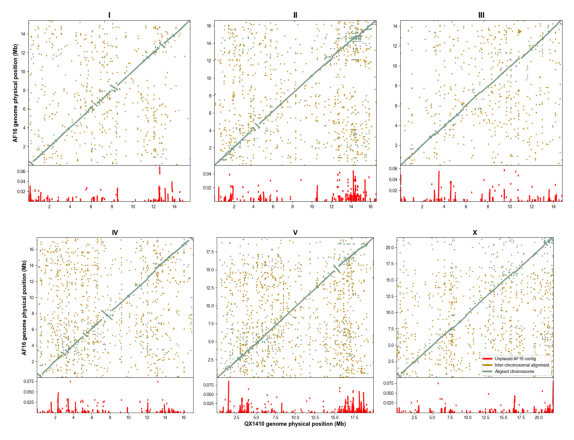

In [13]:
fig_merged = plt.figure(figsize=(7.5, 4.5))

img1 = Image.open("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/plots/plot1.png")
fig_merged.add_subplot(2, 1, 1)  # 2 rows, 1 col, first subplot
plt.imshow(img1)
plt.axis('off') 

img2 = Image.open("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/plots/plot2.png")
fig_merged.add_subplot(2, 1, 2)  # 2 rows, 1 col, second subplot
plt.imshow(img2)
plt.axis('off')  

plt.tight_layout()
plt.show()

fig_merged.savefig("/Users/lanceoconnor/Desktop/JohnsHopkins/ANDERSEN_THESIS/projects/assemblies/plots/AF16_QX1410.jpg", bbox_inches='tight', dpi=900)